In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


## Import Libraries

In [2]:
# Core Data Science Stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling and Evaluation Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Data Loads

In [3]:
df_heart_disease = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')
df_heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
# Display summary information including data types and non-null counts
print("Dataset Summary Info")
df_heart_disease.info()
print("\n Shape of the Dataset")
print(f"Rows: {df_heart_disease.shape[0]}, Columns: {df_heart_disease.shape[1]}")


Dataset Summary Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

 Shape of the Dataset
Rows: 1025, Columns: 14


## Train-Test Split

In [5]:
# Separate features and target
X = df_heart_disease.drop(columns=['target'])
y = df_heart_disease['target']

# Perform a stratified split to keep target distribution balanced across both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (820, 13)
Testing features shape: (205, 13)


## Exploratory Data Analysis (EDA) on Training Data

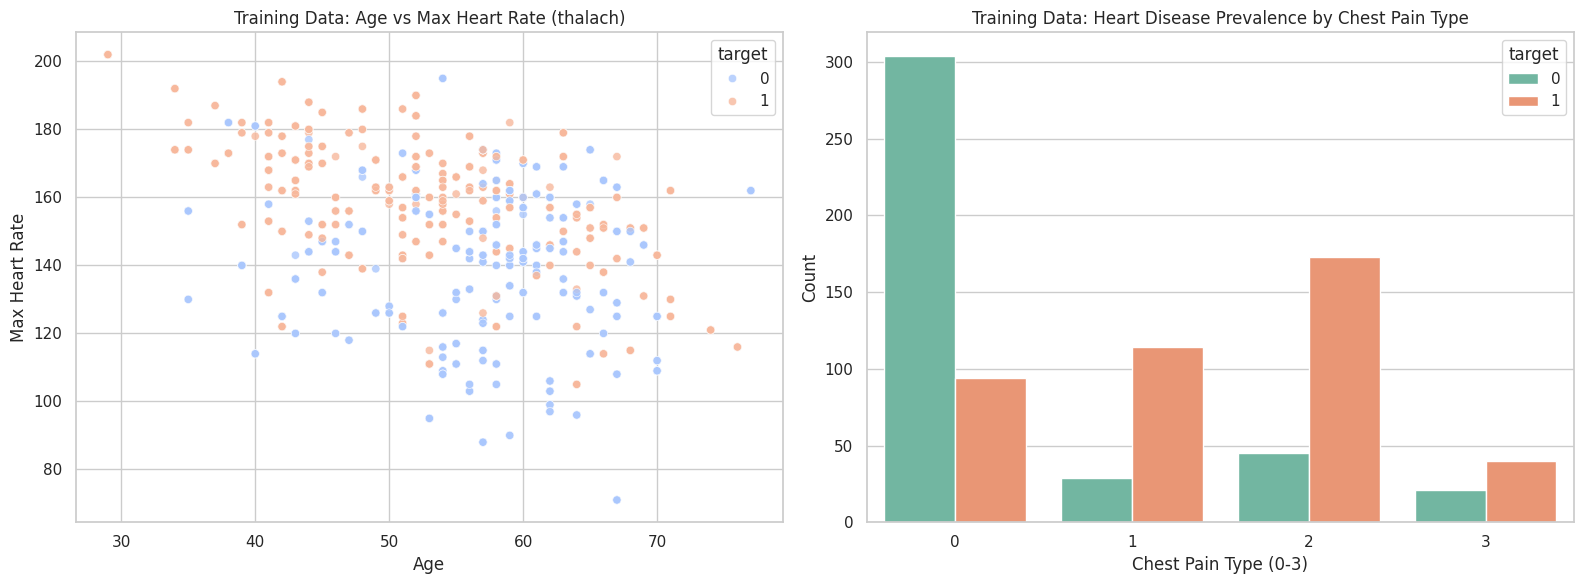

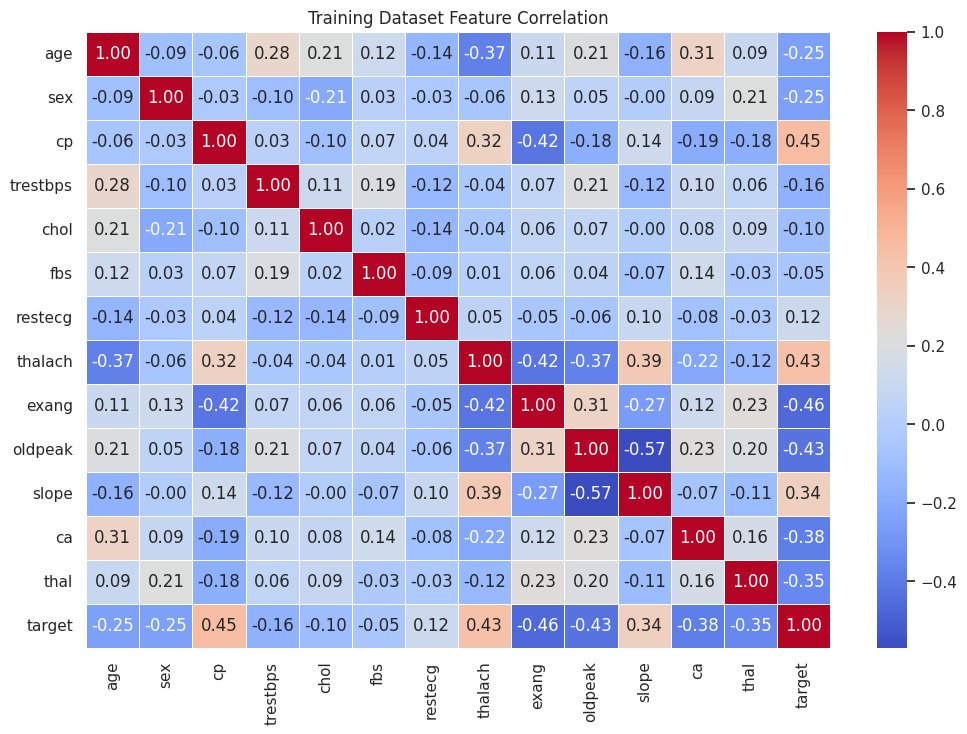

In [6]:
# Create temporary frame strictly for training visualization
train_df = X_train.copy()
train_df['target'] = y_train

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualization 1: Scatter plot tracking Age vs Max Heart Rate
sns.scatterplot(
    ax=axes[0], data=train_df, x='age', y='thalach', hue='target', palette='coolwarm', alpha=0.8
)
axes[0].set_title('Training Data: Age vs Max Heart Rate (thalach)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Max Heart Rate')

# Visualization 2: Bar plot showing target distribution over Chest Pain classes
sns.countplot(
    ax=axes[1], data=train_df, x='cp', hue='target', palette='Set2'
)
axes[1].set_title('Training Data: Heart Disease Prevalence by Chest Pain Type')
axes[1].set_xlabel('Chest Pain Type (0-3)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Global Correlation Heatmap for Training Data
plt.figure(figsize=(12, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Training Dataset Feature Correlation')
plt.show()

## Feature Scaling

In [7]:
scaler = StandardScaler()

# Fit and transform training features, transform test features cleanly
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features successfully normalized around mean=0 and variance=1")

Features successfully normalized around mean=0 and variance=1


## Model Training & Evaluation

Overall Model Accuracy: 80.98%

Classification Report
                precision    recall  f1-score   support

No Disease (0)       0.89      0.70      0.78       100
   Disease (1)       0.76      0.91      0.83       105

      accuracy                           0.81       205
     macro avg       0.82      0.81      0.81       205
  weighted avg       0.82      0.81      0.81       205



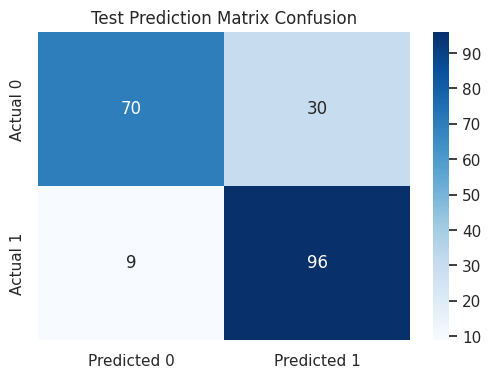

In [8]:
# Instantiate and fit logistic regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict outcomes
y_pred = log_reg.predict(X_test_scaled)

# Metrics evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Disease (1)']))

# Confusion Matrix Visual
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Test Prediction Matrix Confusion')
plt.show()